In [33]:
import pandas as pd
from pathlib import Path
import geopandas as gpd
import matplotlib.pyplot as plt
import glob
import plotly.express as px
import contextily as cx


In [6]:
#Read in the shapefiles from the local directory within a for loop
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'
data_files = Path("../Resources/Shapefiles")
shapefile_dfs = []
for data_file in data_files.glob("*.shp"):
    df = gpd.read_file(data_file)
    shapefile_dfs.append(df)
concat_shapefile_df = pd.concat(shapefile_dfs, ignore_index=True)

concat_shapefile_df.head(1)


,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Status,Connect,Form,TermType,Surging,Linkages,Name,GN_area,GN_comp_ye,geometry
0,RGI60-01.00002,G213332E63404N,20090703,-9999999,-146.668,63.404,1,2,0.558,1713,...,0,0,0,0,9,9,None,0.8415,1986,"POLYGON ((365095.000 1512465.000, 365125.000 1..."


In [67]:
#Determine the number of rows in the concatenated table
concat_shapefile_df.shape

(287327, 25)

DATA EXPLORATION

In [68]:
# View the columns of the shapefile
concat_shapefile_df.columns

Index(['RGIId', 'GLIMSId', 'BgnDate', 'EndDate', 'CenLon', 'CenLat',
       'O1Region', 'O2Region', 'Area', 'Zmin', 'Zmax', 'Zmed', 'Slope',
       'Aspect', 'Lmax', 'Status', 'Connect', 'Form', 'TermType', 'Surging',
       'Linkages', 'Name', 'GN_area', 'GN_comp_ye', 'geometry'],
      dtype='object')

In [9]:
#Copy the shapefile dataframe
shapefile_df = concat_shapefile_df.copy()
shapefile_df.head()


,RGIId,GLIMSId,BgnDate,EndDate,CenLon,CenLat,O1Region,O2Region,Area,Zmin,...,Status,Connect,Form,TermType,Surging,Linkages,Name,GN_area,GN_comp_ye,geometry
0,RGI60-01.00002,G213332E63404N,20090703,-9999999,-146.668,63.404,1,2,0.558,1713,...,0,0,0,0,9,9,None,0.8415,1986,"POLYGON ((365095.000 1512465.000, 365125.000 1..."
1,RGI60-01.00003,G213920E63376N,20090703,-9999999,-146.080,63.376,1,2,1.685,1609,...,0,0,0,0,9,9,None,1.1295,1986,"POLYGON ((394645.000 1512465.000, 394675.000 1..."
2,RGI60-01.00004,G213880E63381N,20090703,-9999999,-146.120,63.381,1,2,3.681,1273,...,0,0,0,0,9,9,None,1.9764,1986,"MULTIPOLYGON (((392485.000 1512435.000, 392485..."
3,RGI60-01.00005,G212943E63551N,20090703,-9999999,-147.057,63.551,1,2,2.573,1494,...,0,0,0,0,9,9,None,0.1584,1986,"POLYGON ((343285.000 1526025.000, 343315.000 1..."
4,RGI60-01.00006,G213756E63571N,20090703,-9999999,-146.244,63.571,1,2,10.470,1201,...,0,0,0,0,9,9,None,7.2504,1986,"MULTIPOLYGON (((385495.000 1537035.000, 385855..."


In [10]:
# Drop the irrelevant columns
shapefile_df_reduced = shapefile_df[["GLIMSId","CenLon", "CenLat", "Zmin", "Zmax", "Slope", "Lmax", "Form", "Name", "GN_area", "GN_comp_ye", "geometry"]]
shapefile_df_reduced.head()



,GLIMSId,CenLon,CenLat,Zmin,Zmax,Slope,Lmax,Form,Name,GN_area,GN_comp_ye,geometry
0,G213332E63404N,-146.668,63.404,1713,2144,16.0,1197,0,None,0.8415,1986,"POLYGON ((365095.000 1512465.000, 365125.000 1..."
1,G213920E63376N,-146.080,63.376,1609,2182,18.0,2106,0,None,1.1295,1986,"POLYGON ((394645.000 1512465.000, 394675.000 1..."
2,G213880E63381N,-146.120,63.381,1273,2317,19.0,4175,0,None,1.9764,1986,"MULTIPOLYGON (((392485.000 1512435.000, 392485..."
3,G212943E63551N,-147.057,63.551,1494,2317,16.0,2981,0,None,0.1584,1986,"POLYGON ((343285.000 1526025.000, 343315.000 1..."
4,G213756E63571N,-146.244,63.571,1201,3547,22.0,10518,0,None,7.2504,1986,"MULTIPOLYGON (((385495.000 1537035.000, 385855..."


In [18]:
#Compute the change in area between 1986 and 2020 for each glacier

area_1986_df = shapefile_df_reduced.loc[shapefile_df_reduced["GN_comp_ye"]== 1986, ["GLIMSId", "CenLon", "CenLat","GN_area","geometry"]]
area_2020_df = shapefile_df_reduced.loc[shapefile_df_reduced["GN_comp_ye"]== 2020, ["GLIMSId","CenLon", "CenLat","GN_area","geometry"]] 

joined_area_df = area_1986_df.merge(area_2020_df, on=['GLIMSId'], how="left")


renamed_df = joined_area_df.rename(columns={"CenLon_x": "longitude_1986", "CenLat_x":"latitude_1986",'GN_area_x': "area_1986", "GN_area_y": "area_2020", "geometry_x":"polygons_1986", "CenLon_y": "longitude_2020", "CenLat_y": "latitude_2020", "geometry_y": "polygons_2020"})



area_change = renamed_df["area_2020"] - renamed_df["area_1986"]

renamed_df["change_in_area"] = area_change

renamed_df.head()




(17267, 5)

In [66]:
#Compute the total change in area between 1986 and 2020 in km2
total_change = renamed_df["change_in_area"].sum()
total_change

-8544.0717

In [13]:
#Determine the number of glaciers that shrank in size between 1986 and 2020
glacier_retreat_no = renamed_df.iloc[:,9][renamed_df.iloc[:,9]<0].count()
glacier_retreat_no





11652

In [14]:
#Determine the number of glaciers that grew in size between 1986 and 2020
glacier_enlarged = renamed_df.iloc[:,9][renamed_df.iloc[:,9] > 0].count()
glacier_enlarged

2116

In [15]:
total_glacier_change_count = renamed_df.iloc[:,5].count()
total_glacier_change_count

13786

In [43]:

# Make a dataframe for plotting the change in area between 1986 and 2020


area_1986_df_plot = shapefile_df_reduced.loc[shapefile_df_reduced["GN_comp_ye"]== "1986", ["GLIMSId","geometry","GN_comp_ye"]]
area_2020_df_plot = shapefile_df_reduced.loc[shapefile_df_reduced["GN_comp_ye"]== "2020", ["GLIMSId","geometry", "GN_comp_ye"]] 




# Rename the Year column 

renamed_1986_df = area_1986_df_plot.rename(columns= {"GN_comp_ye": "Year"})
renamed_2020_df = area_2020_df_plot.rename(columns= {"GN_comp_ye": "Year"})


# Create a new column with unique ids for each glacier 

renamed_1986_df["Unique_glacier_id"] = renamed_1986_df["GLIMSId"].astype(str) + '_' + renamed_1986_df["Year"].astype(str)
renamed_1986_df_reduced = renamed_1986_df[["Unique_glacier_id","geometry"]]

renamed_2020_df["Unique_glacier_id"] = renamed_2020_df["GLIMSId"].astype(str) + '_' + renamed_2020_df["Year"].astype(str)
renamed_2020_df_reduced = renamed_2020_df[["Unique_glacier_id","geometry"]]










C:\Users\didem\AppData\Local\Temp\ipykernel_23976\1958107553.py:2: UserWarning: The indices of the two GeoSeries are different.
  df_difference = renamed_1986_df_reduced.difference(renamed_2020_df_reduced)


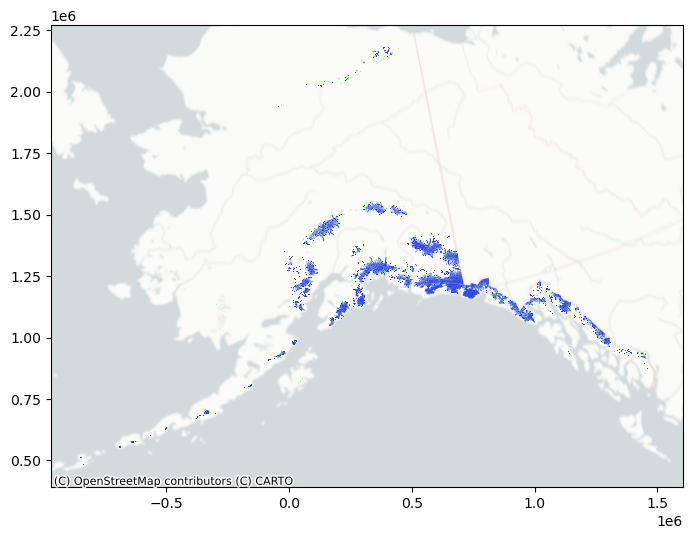

In [64]:
# Save the area difference to a variable 
df_difference = renamed_1986_df_reduced.difference(renamed_2020_df_reduced)


fig, ax = plt.subplots(figsize= (10,6))
renamed_1986_df_reduced.plot(ax=ax, color="lightgreen",label = "1986", alpha= 0.7)
renamed_2020_df_reduced.plot(ax=ax, color="blue",label = "2020", alpha = 0.7)
df_difference.plot(ax=ax, color="red",label = "Area Difference", alpha = 1)
cx.add_basemap (ax, source = cx.providers.CartoDB.Positron, crs= renamed_1986_df_reduced.crs)
plt.show()




### Save the shapefile dataframe to a csv
concat_shapefile_df.to_csv('shapefiles.csv', index=False)

In [63]:
#Get the EPSG information for the shapefiles
renamed_1986_df_reduced.crs

<Projected CRS: EPSG:3338>
Name: NAD83 / Alaska Albers
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: United States (USA) - Alaska.
- bounds: (172.42, 51.3, -129.99, 71.4)
Coordinate Operation:
- name: Alaska Albers (meter)
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich